# Gene statistics

A few anaylses to analyze gene statistics and place them in context with other species.

In [1]:
import gene_stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

prefix = "NSv0.8_hap2_LG"
gff_file = "../PO2744_Nanomia.annotation.gff"

In [2]:
# Call the main function and store the returned DataFrames
df_genes, df_exons, df_introns = gene_stats.gene_stats(gff_file, prefix)

Reading file: ../PO2744_Nanomia.annotation.gff
File type: FileType.GFF
Number of rows read: 244308
Number of rows after removing duplicates: 244308
Number of rows after filtering by prefix: 244308
Genes DataFrame:
                  seqid source  type    start      end score strand phase  \
58612   NSv0.8_hap2_LG1  maker  gene   193111   193533     .      -     .   
58616   NSv0.8_hap2_LG1  maker  gene   808002   808783     .      +     .   
211123  NSv0.8_hap2_LG1  maker  gene  1356349  1361772     .      -     .   
211127  NSv0.8_hap2_LG1  maker  gene  1751120  1751565     .      +     .   
211133  NSv0.8_hap2_LG1  maker  gene  1751667  1753534     .      +     .   

                                               attributes   gene_ID        ID  \
58612       ID=ANN00001;Note=Protein of unknown function;  ANN00001  ANN00001   
58616   ID=ANN00002;Note=Similar to Fcn1: Ficolin-1 (R...  ANN00002  ANN00002   
211123  ID=ANN00003;Note=Similar to pol: Pro-Pol polyp...  ANN00003  ANN00003   

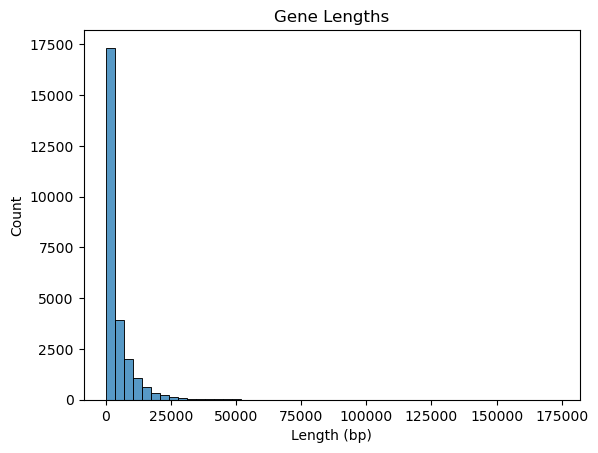

In [4]:
# Histogram of gene lengths
plt.figure()
sns.histplot(df_genes["length"], bins=50)
plt.title("Gene Lengths")
plt.xlabel("Length (bp)")
plt.ylabel("Count")
plt.show()

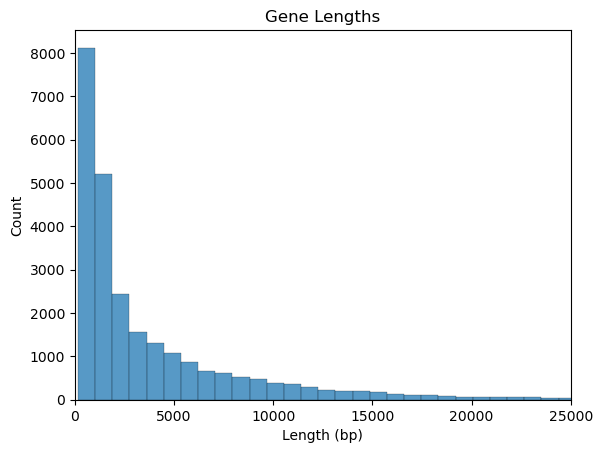

In [5]:
# Histogram of gene lengths up to 25000 bp

plt.figure()
sns.histplot(df_genes["length"], bins=200)
plt.xlim(0, 25000)
plt.title("Gene Lengths")
plt.xlabel("Length (bp)")
plt.ylabel("Count")
plt.show()

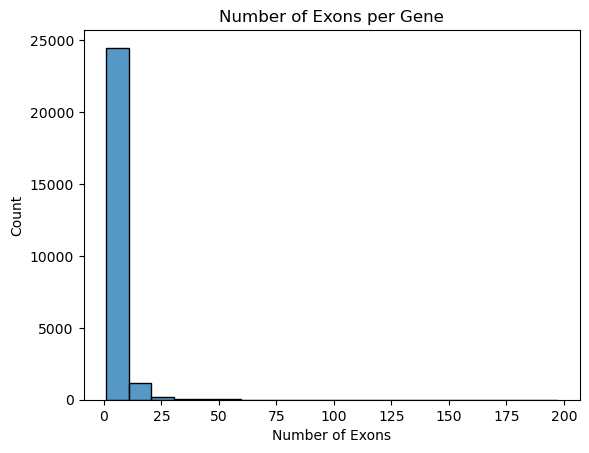

In [6]:
# histogram of number of exons per gene
plt.figure()
sns.histplot(df_genes["num_exons"], bins=20)
plt.title("Number of Exons per Gene")
plt.xlabel("Number of Exons")
plt.ylabel("Count")
plt.show()

In [23]:
length_introns = df_introns["length"].sum()
length_exons = df_exons["length"].sum()
length_genes = df_genes["length"].sum()
print(f"Total intron length: {length_introns/1e6} Mb")
print(f"Total exon length: {length_exons/1e6} Mb")
print(f"Total gene length: {length_genes/1e6} Mb")
print(f"Intron ratio: {length_introns/length_exons:.2f}")


Total intron length: 70.667468 Mb
Total exon length: 37.339047 Mb
Total gene length: 109.625898 Mb
Intron ratio: 1.89


## Hydractinia symbiologicarpus

Ingest and analyze annotations from HSymV2.0.gtf at https://figshare.com/articles/dataset/HSymV2_0_a_chromosome-level_genome_assembly_of_Hydractinia_symbiolongicarpus/22126232/1?file=39369317 .

In [22]:
# Call the main function and store the returned DataFrames
df_genes_hydractinia, df_exons_hydractinia, df_introns_hydractinia = gene_stats.gene_stats("HSymV2.0.gtf", prefix=None)

# Display the intron ratio, ie the total length of introns divided by total length of exons
length_introns_hydractinia = df_introns_hydractinia["length"].sum()
length_exons_hydractinia = df_exons_hydractinia["length"].sum()
length_genes_hydractinia = df_genes_hydractinia["length"].sum()
print(f"Total intron length: {length_introns_hydractinia/1e6} Mb")
print(f"Total exon length: {length_exons_hydractinia/1e6} Mb")
print(f"Total gene length: {length_genes_hydractinia/1e6} Mb")
print(f"Intron ratio: {length_introns_hydractinia/length_exons_hydractinia:.2f}")


Reading file: HSymV2.0.gtf
File type: FileType.GTF
Number of rows read: 421084
Number of rows after removing duplicates: 412337
Total intron length: 107.387182 Mb
Total exon length: 39.333974 Mb
Total gene length: 151.192974 Mb
Intron ratio: 2.73


## Intron ratio analyses

Added Nanomia septata and Hydractinia symbiolongicarpus to dataset of Glick et al 2024 - https://doi.org/10.1093/molbev/msae248

In [9]:
df_glick = pd.read_csv("supp_tables_glick2024_modified.csv")

print(df_glick.shape)

(592, 16)


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

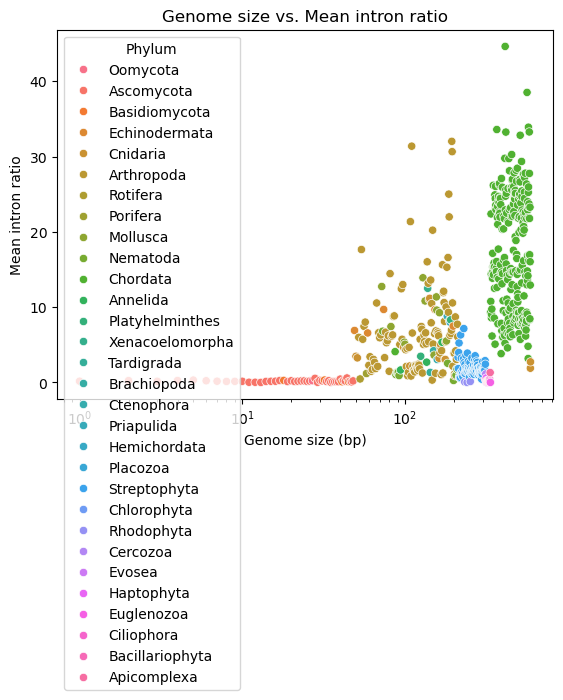

In [13]:
# Use seaborn to make a scatter plot of `Genome size` on x and `Mean intron ratio` on y and color points by `Phylum`

plt.figure()
sns.scatterplot(data=df_glick, x="Genome size", y="Mean intron ratio", hue="Phylum")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Genome size (bp)")
plt.ylabel("Mean intron ratio")
plt.title("Genome size vs. Mean intron ratio")

# Add a legend with a title to sidebar
plt.legend(title="Phylum")

plt.show()

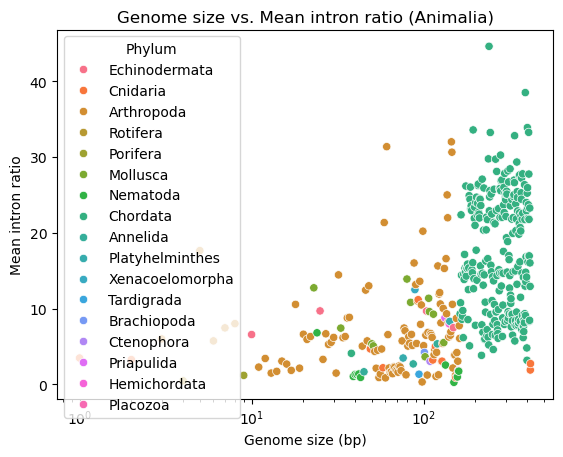

In [14]:
df_animalia = df_glick[df_glick["Kingdom"] == "Animalia"]

plt.figure()
sns.scatterplot(data=df_animalia, x="Genome size", y="Mean intron ratio", hue="Phylum")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Genome size (bp)")
plt.ylabel("Mean intron ratio")
plt.title("Genome size vs. Mean intron ratio (Animalia)")
plt.legend(title="Phylum")
plt.show()

In [17]:
# Make a table of the unique Phyla in the Animalia and the number or rows for each
print(df_animalia["Phylum"].value_counts())

Chordata           255
Arthropoda         112
Cnidaria            12
Mollusca            11
Nematoda            10
Echinodermata        5
Annelida             3
Platyhelminthes      2
Porifera             1
Rotifera             1
Xenacoelomorpha      1
Tardigrada           1
Brachiopoda          1
Ctenophora           1
Priapulida           1
Hemichordata         1
Placozoa             1
Name: Phylum, dtype: int64


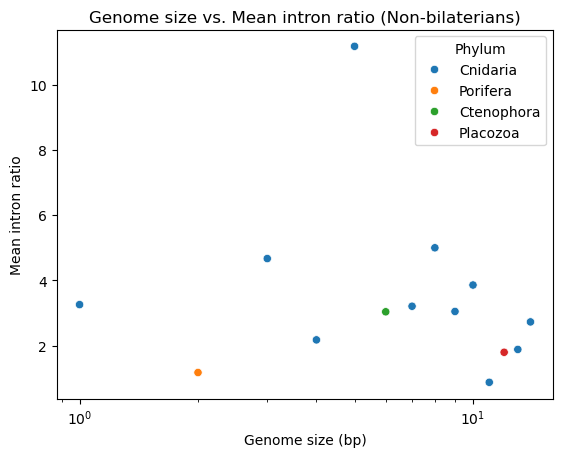

In [16]:
# subset to only include non-bilaterians
nonbilateria = ["Cnidaria", "Porifera", "Placozoa", "Ctenophora"]
df_nonbilat = df_animalia[df_animalia["Phylum"].isin(nonbilateria)]

plt.figure()
sns.scatterplot(data=df_nonbilat, x="Genome size", y="Mean intron ratio", hue="Phylum")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Genome size (bp)")
plt.ylabel("Mean intron ratio")
plt.title("Genome size vs. Mean intron ratio (Non-bilaterians)")
plt.legend(title="Phylum")
plt.show()

There is no strong relationship between intron ratio and genome size within Cnidaria. Check some other animals.

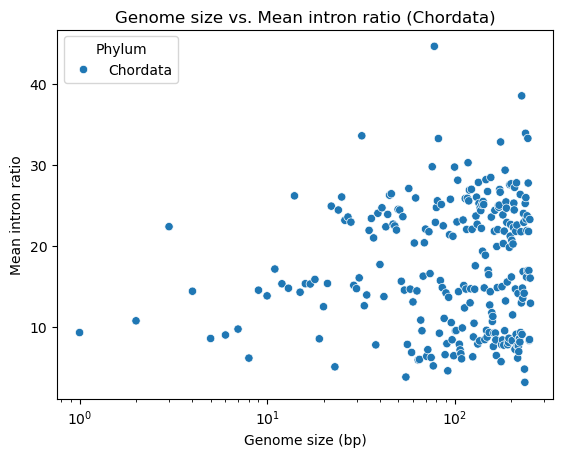

In [19]:
# plot Chordata separately
df_chordata = df_animalia[df_animalia["Phylum"] == "Chordata"]

plt.figure()
sns.scatterplot(data=df_chordata, x="Genome size", y="Mean intron ratio", hue="Phylum")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Genome size (bp)")
plt.ylabel("Mean intron ratio")
plt.title("Genome size vs. Mean intron ratio (Chordata)")

# Add a legend with a title to sidebar
plt.legend(title="Phylum")

plt.show()

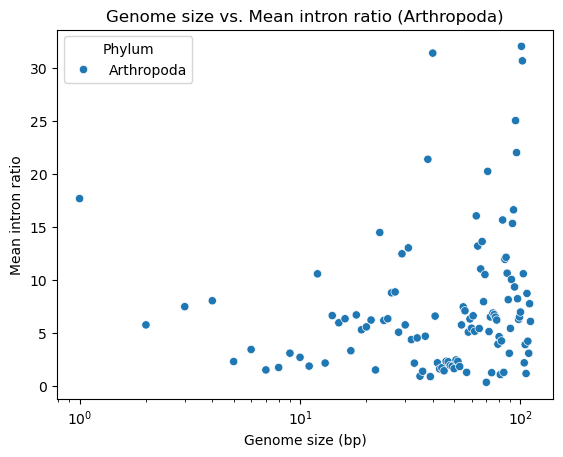

In [20]:
# same for arthropoda

df_arthropoda = df_animalia[df_animalia["Phylum"] == "Arthropoda"]

plt.figure()
sns.scatterplot(data=df_arthropoda, x="Genome size", y="Mean intron ratio", hue="Phylum")
plt.xscale("log")
plt.xlabel("Genome size (bp)")
plt.ylabel("Mean intron ratio")
plt.title("Genome size vs. Mean intron ratio (Arthropoda)")
plt.legend(title="Phylum")
plt.show()

Other phyla don't have many members in the dataset.

A few observations:
- Within these groups there are very large genomes with low intron ratios, so intron ratios often do not increase much with genome size.
- Some large genomes have large intron ratios compared to animals with small genomes, but it is far from universal.